In [ ]:
!git clone https://github.com/matteogirellipolito/ML_Project
%cd ML_Project/eval
!git pull

Cloning into 'ML_Project'...
remote: Enumerating objects: 1112, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 1112 (delta 15), reused 32 (delta 12), pack-reused 1071 (from 2)
Receiving objects: 100% (1112/1112), 27.07 MiB | 13.26 MiB/s, done.
Resolving deltas: 100% (526/526), done.
/content/ML_Project/eval
Already up to date.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! pip install ood_metrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you hav

#Calcolo delle metriche sui vari dataset per ERFNET

In [ ]:
!python evalAnomaly.py --input "/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/*.jpg"
!python evalAnomaly.py --input "/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly21/images/*.png"
!python evalAnomaly.py --input "/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadObsticle21/images/*.webp"
!python evalAnomaly.py --input "/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/fs_static/images/*.jpg"
!python evalAnomaly.py --input "/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/FS_LostFound_full/images/*.png"

Loading model: ../trained_models/erfnet.py
Loading weights: ../trained_models/erfnet_pretrained.pth
Model and weights LOADED successfully
/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/49.jpg
/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/48.jpg
/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/58.jpg
/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/59.jpg
/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/56.jpg
/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/33.jpg
/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/38.jpg
/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/22.jpg
/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/9.jpg

#Calcolo mIoU per ERFNET

In [ ]:
!pip install cityscapesscripts

import os
os.environ['CITYSCAPES_DATASET'] = '/content/drive/MyDrive/Anomaly_Validation_Datasets/Cityscapes_val'

!python -m cityscapesscripts.preparation.createTrainIdLabelImgs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.6/473.6 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.0 MB/s eta 0:00:00
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=bf161983ea6ccc630bb945ab40f846c203cec0c2e93ba5e4a89ebf6ca5e62eb0
  Stored in directory: /root/.cache/pip/wheels/12/98/52/2bffe242a9a487f00886e43b8ed8dac46456702e11a0d6abef
Successfully built typing


Processing 500 annotation files
Progress: 100.0 % 

In [ ]:
!python eval_iou.py \
  --datadir /content/drive/MyDrive/Anomaly_Validation_Datasets/Cityscapes_val/ \
  --subset val

Loading model: ../trained_models/erfnet.py
Loading weights: ../trained_models/erfnet_pretrained.pth
Model and weights LOADED successfully
/content/drive/MyDrive/Anomaly_Validation_Datasets/Cityscapes_val/leftImg8bit/val /content/drive/MyDrive/Anomaly_Validation_Datasets/Cityscapes_val/gtFine/val
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller th

#Heatmap delle varie metriche su alcuni dataset

Model LOADED
Processing: /content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/49.jpg
Processing: /content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/48.jpg
Processing: /content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/58.jpg
Processing: /content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/59.jpg
Processing: /content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/56.jpg
Processing: /content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/33.jpg
Processing: /content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/38.jpg
Processing: /content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/22.jpg
Processing: /content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/9.jpg
Processing: /con

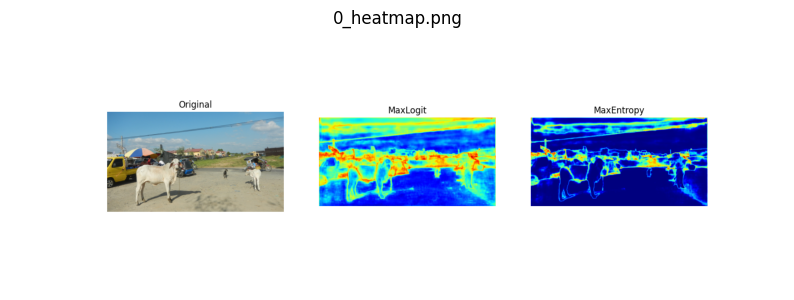

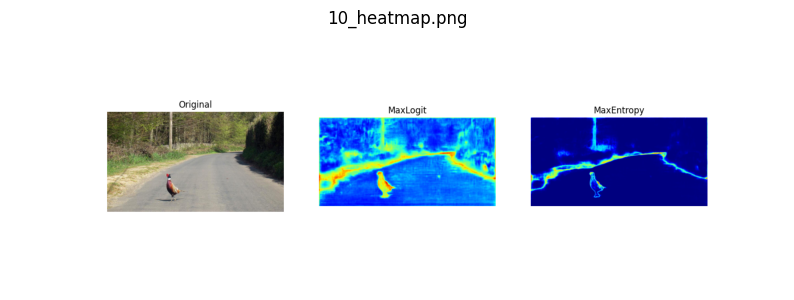

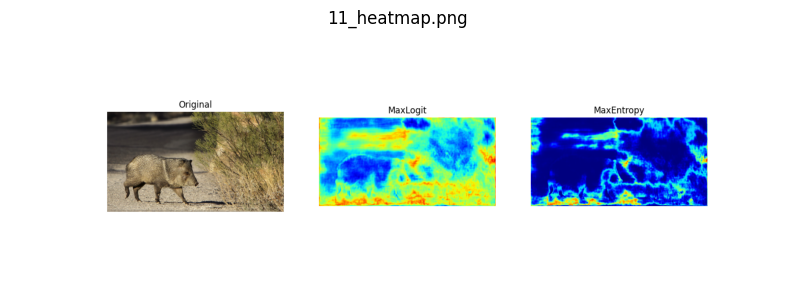

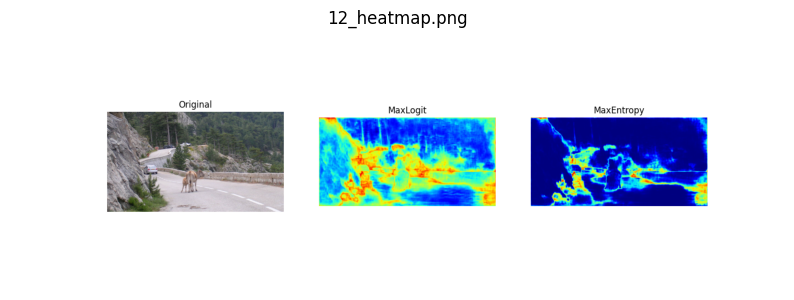

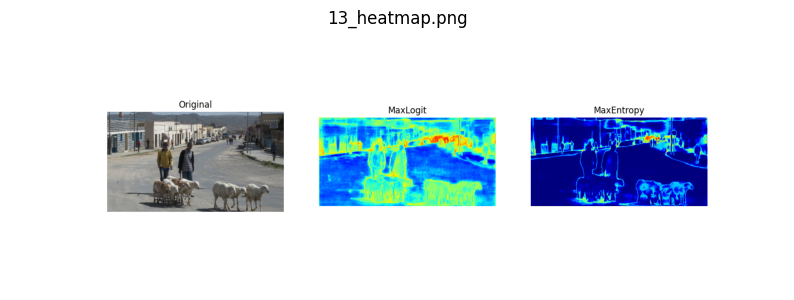

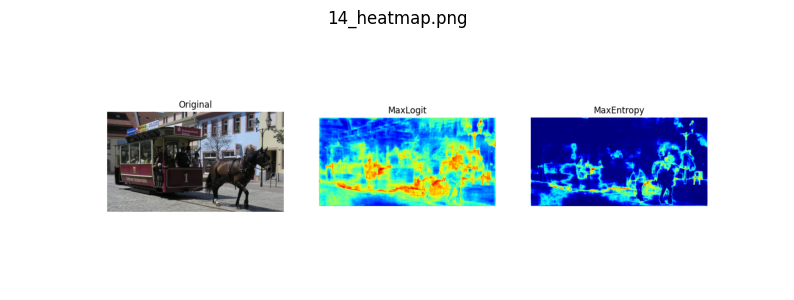

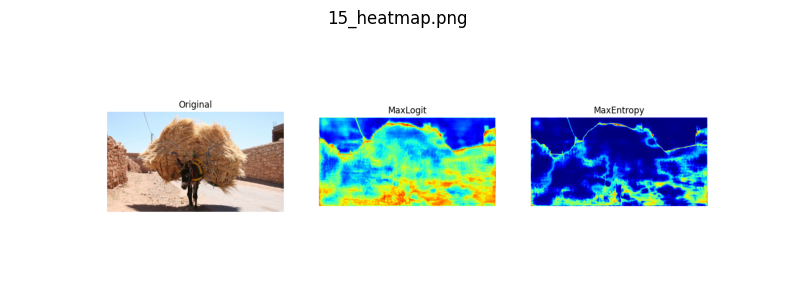

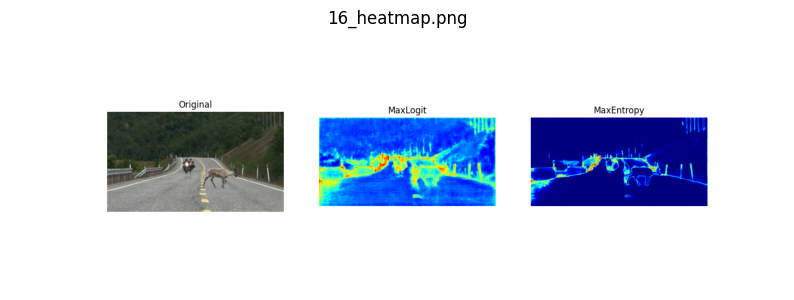

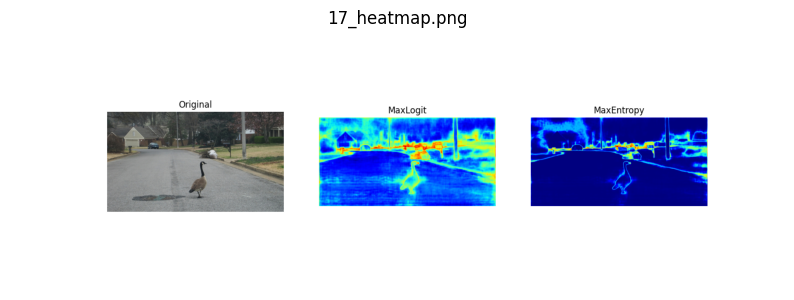

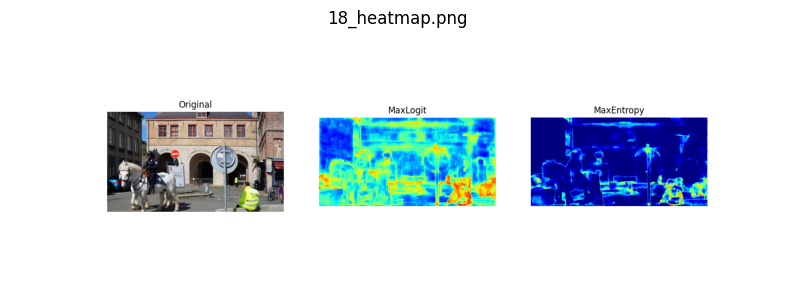

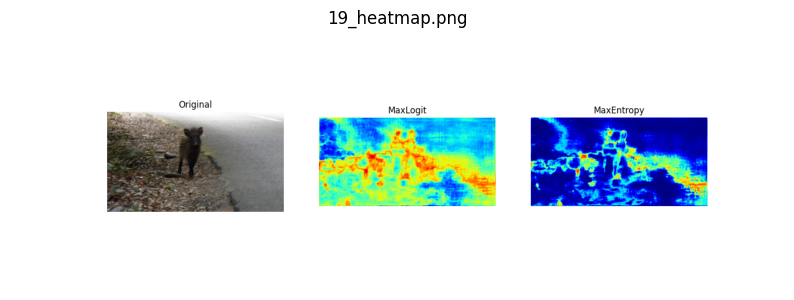

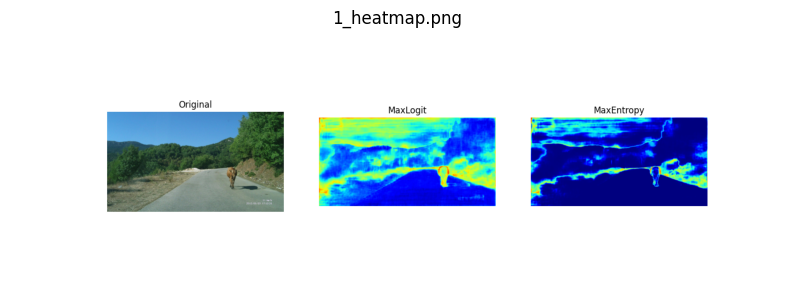

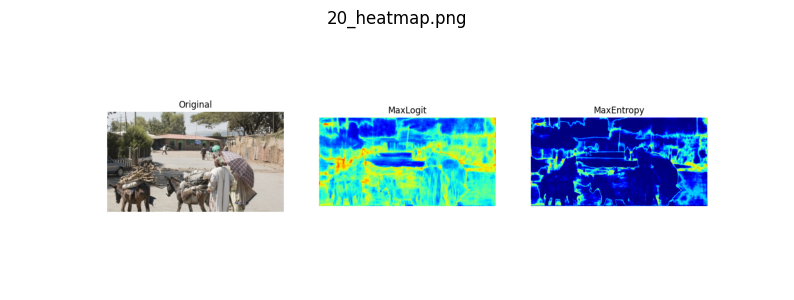

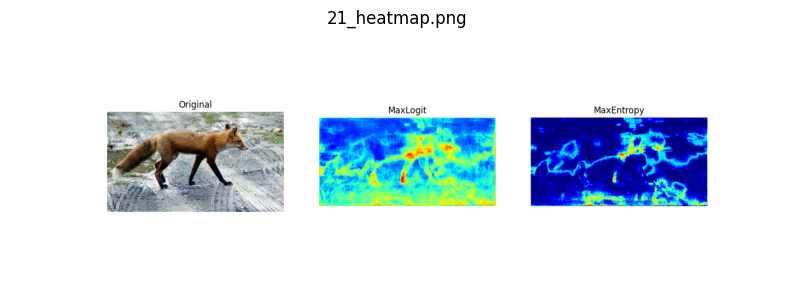

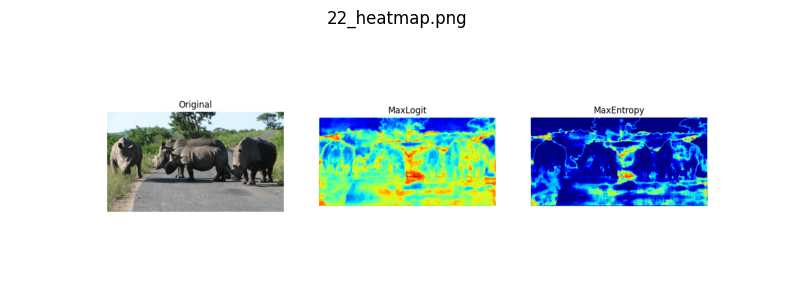

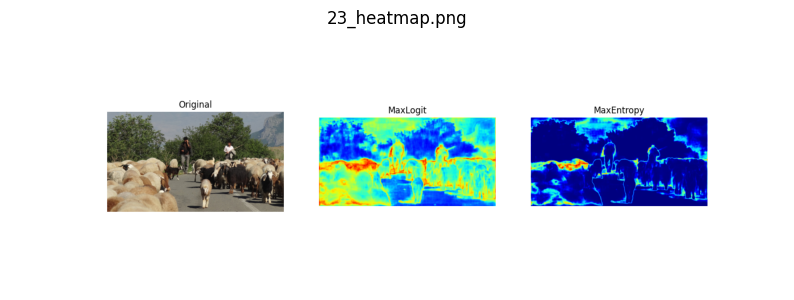

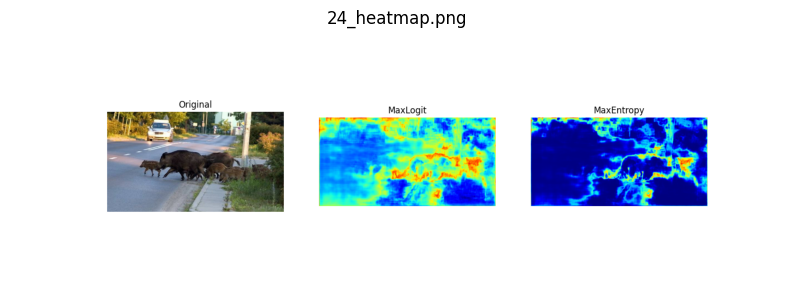

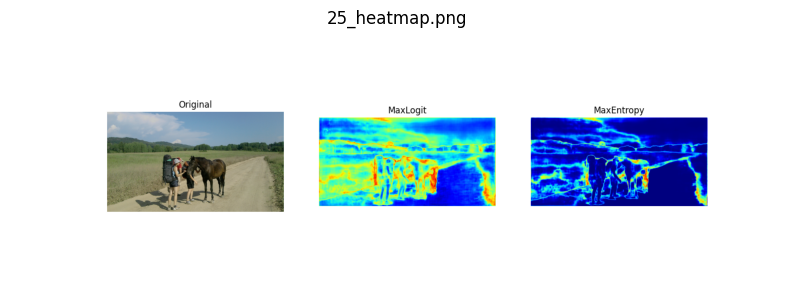

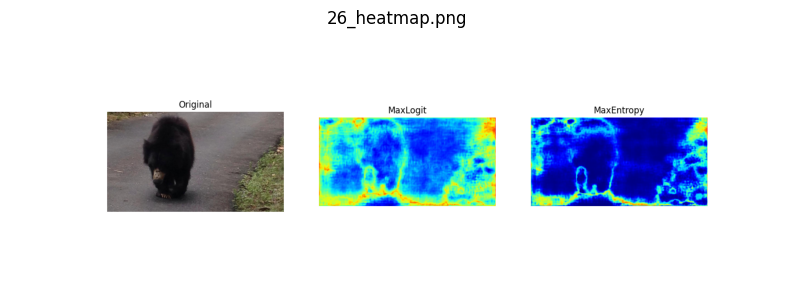

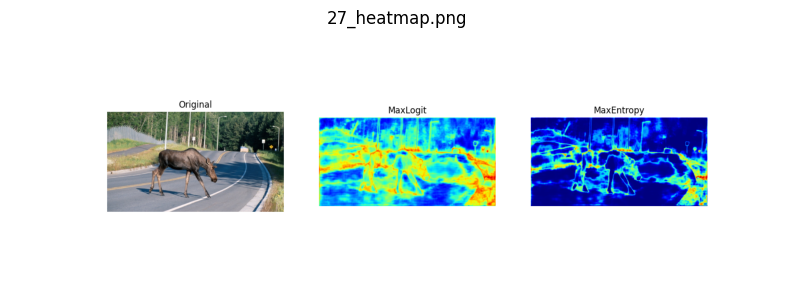

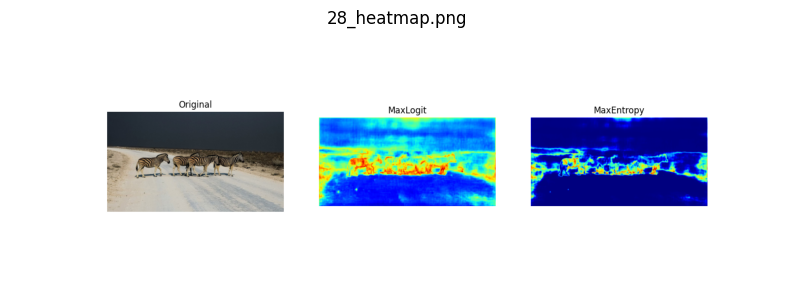

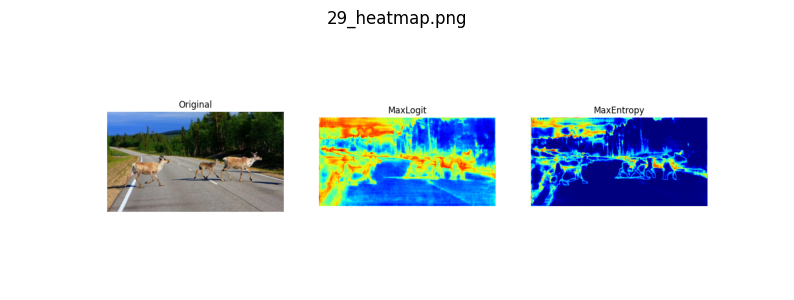

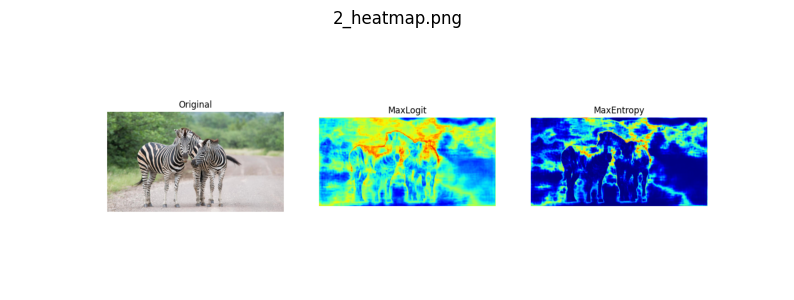

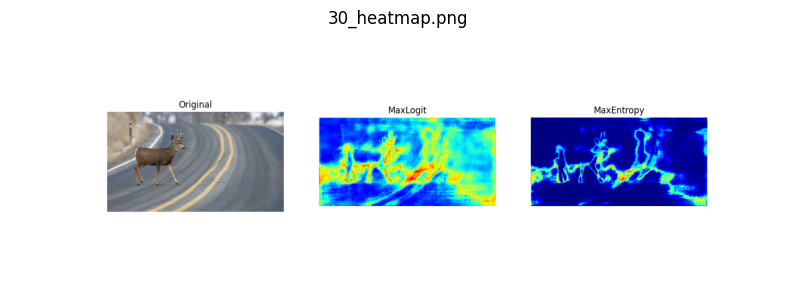

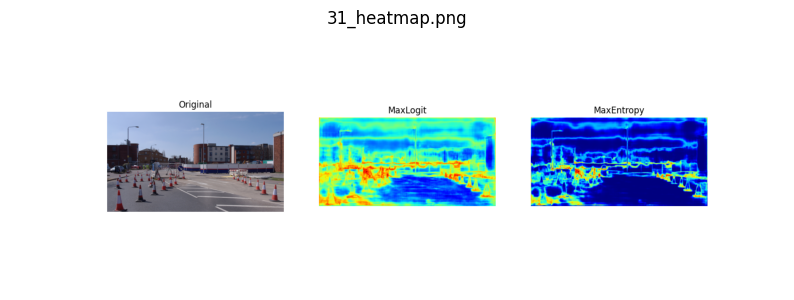

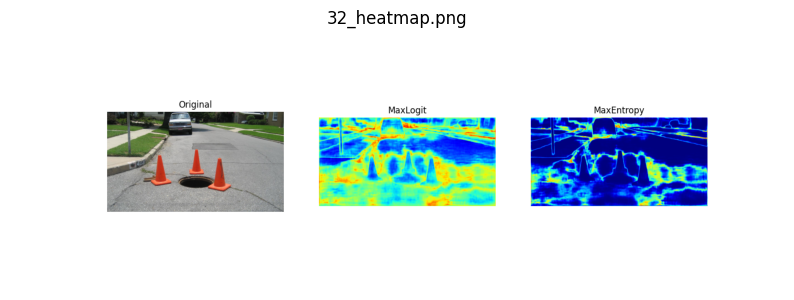

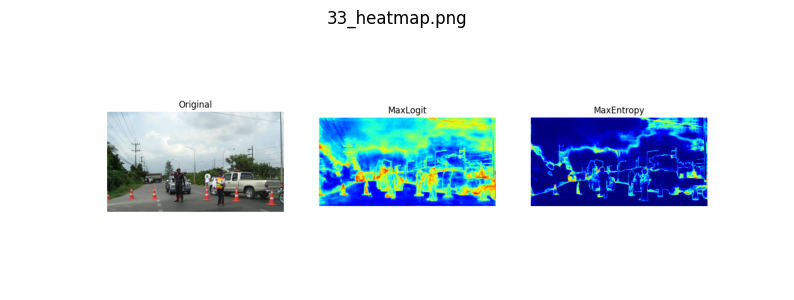

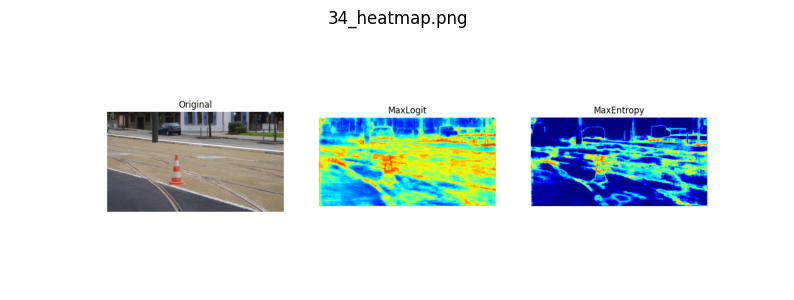

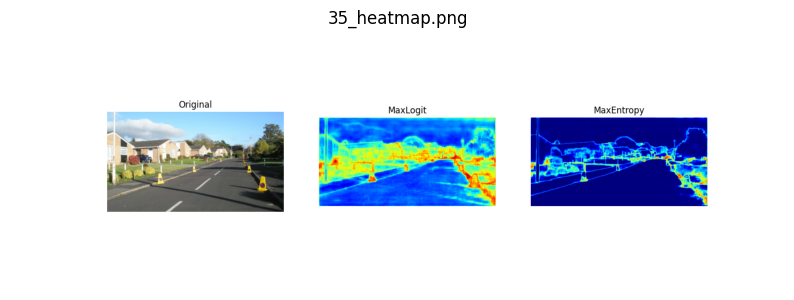

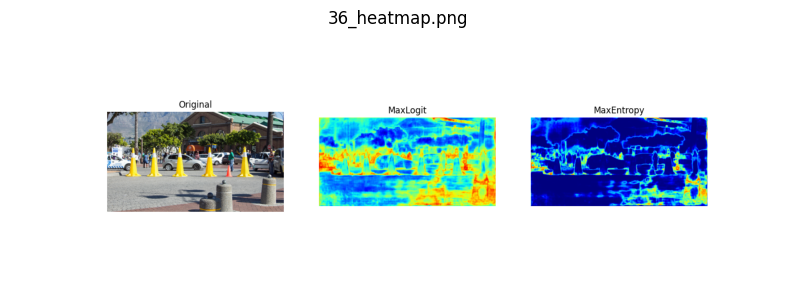

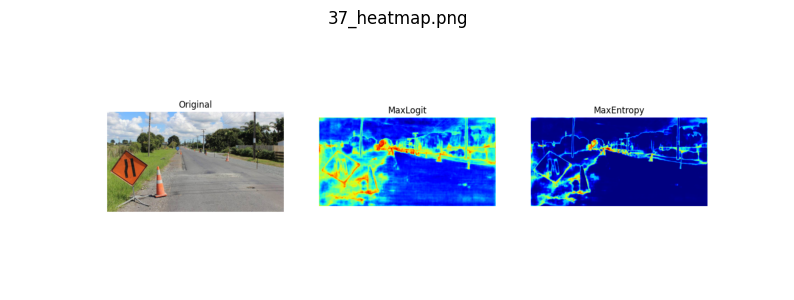

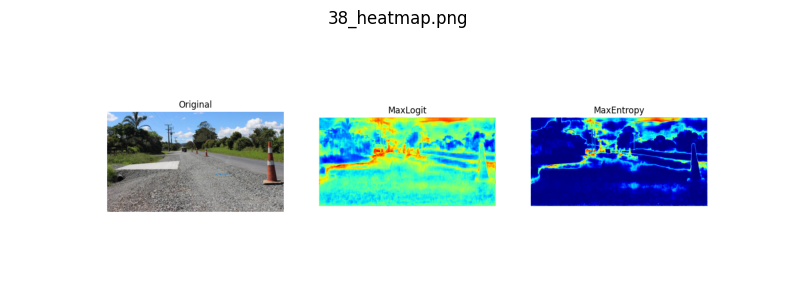

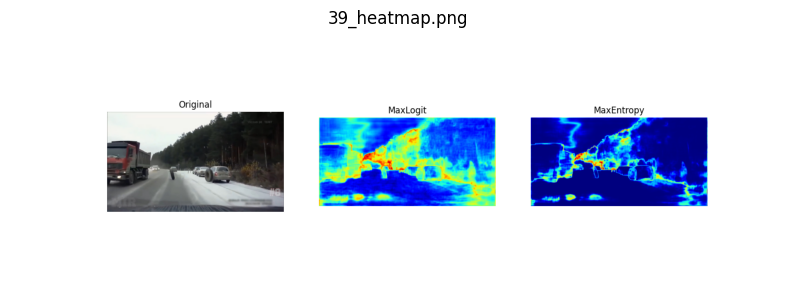

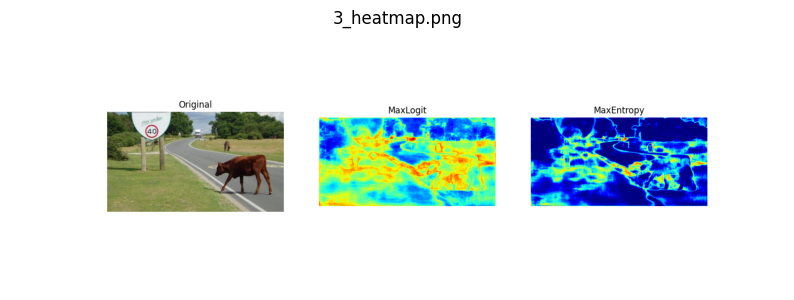

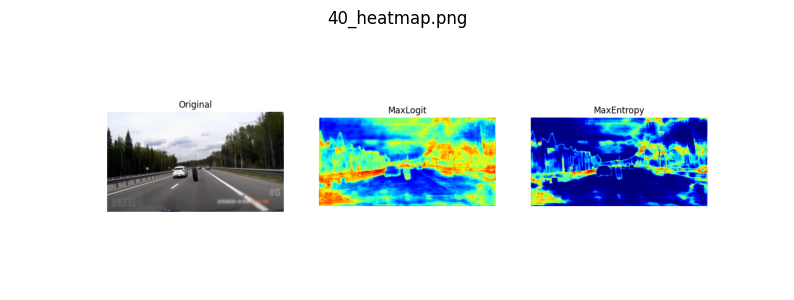

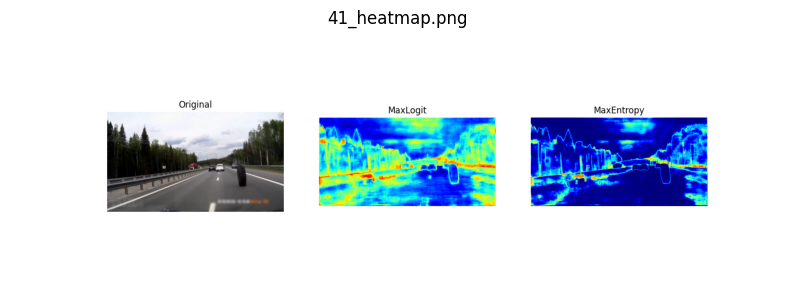

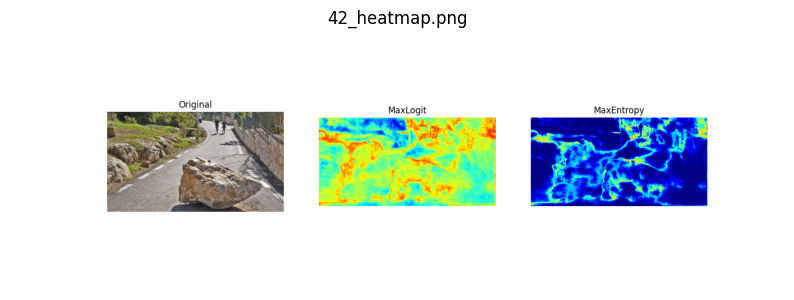

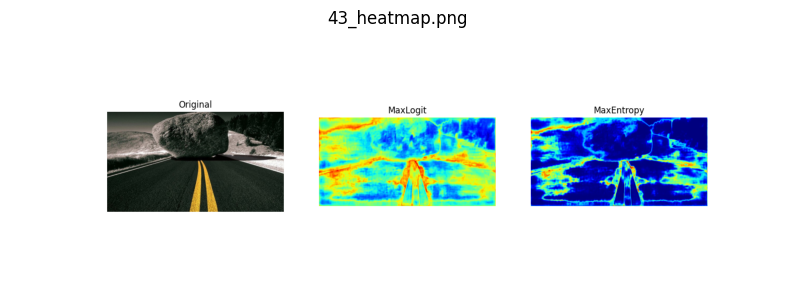

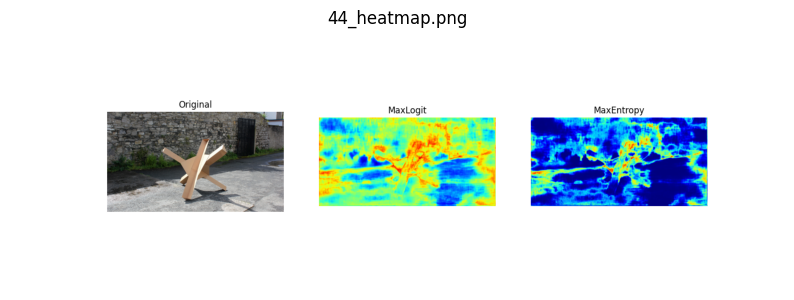

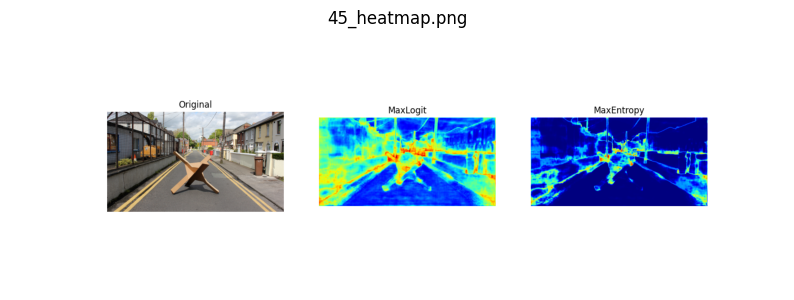

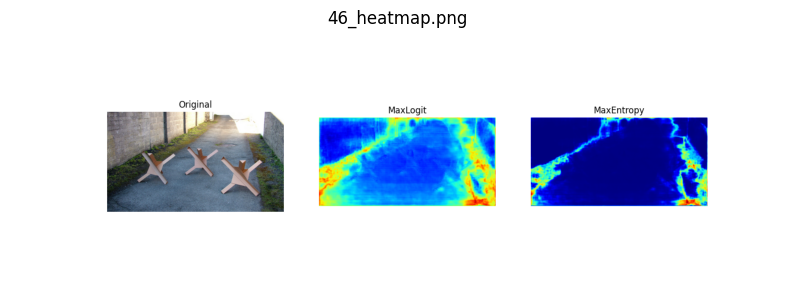

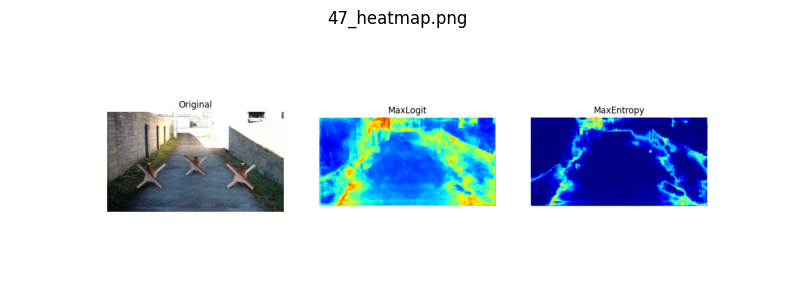

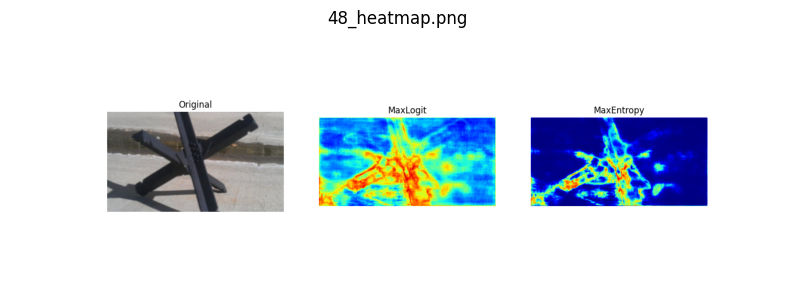

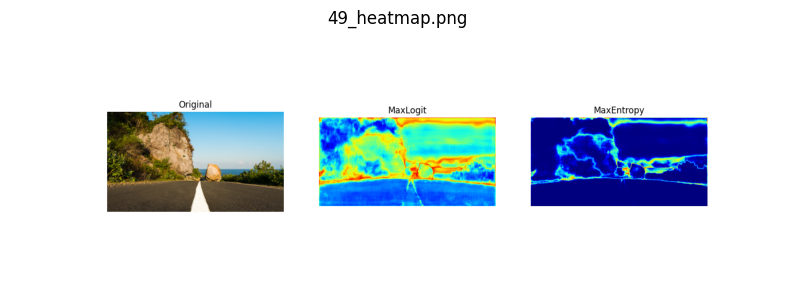

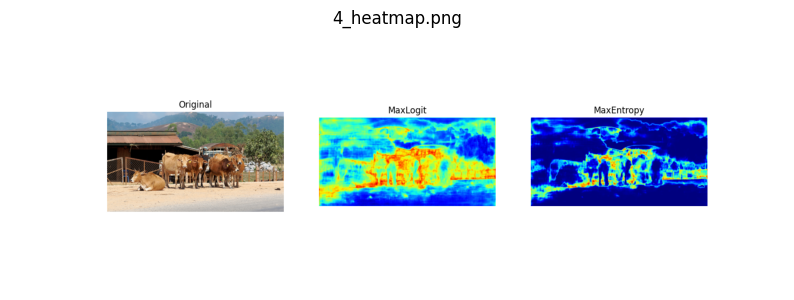

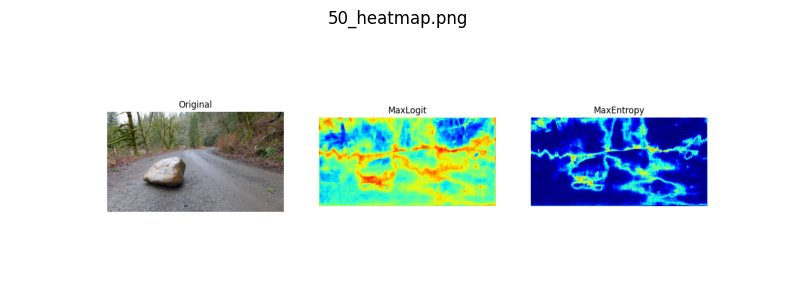

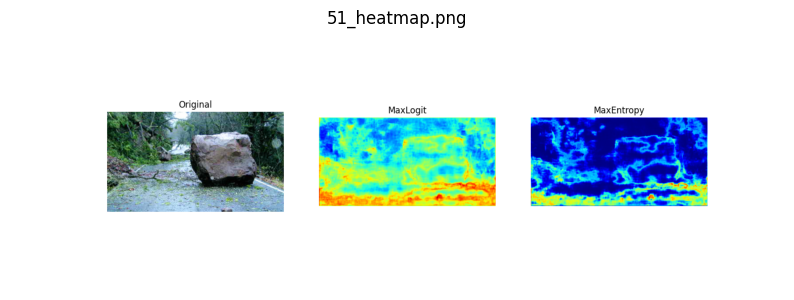

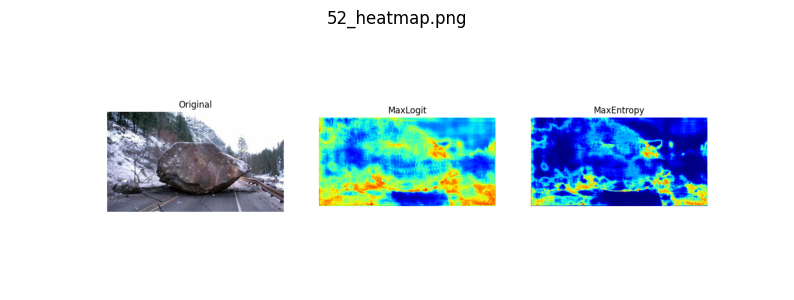

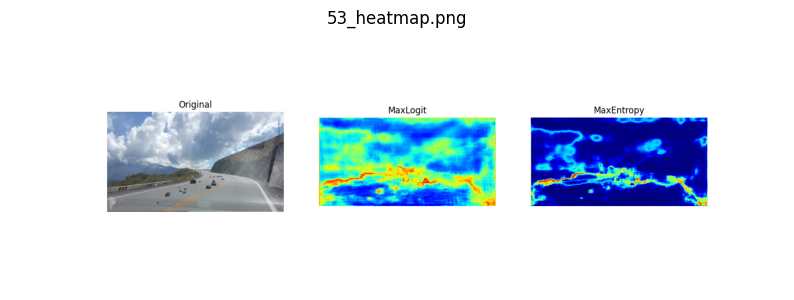

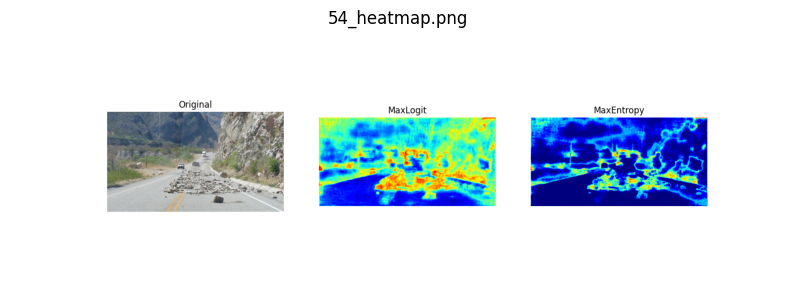

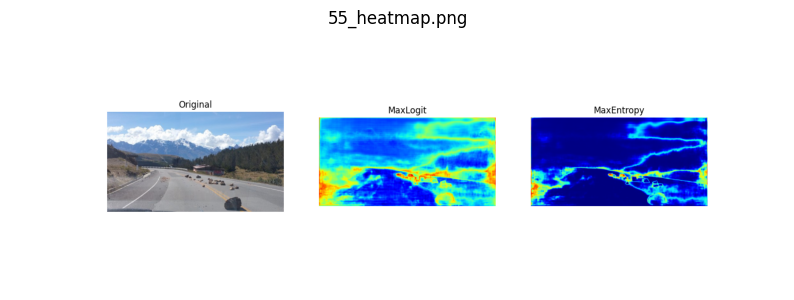

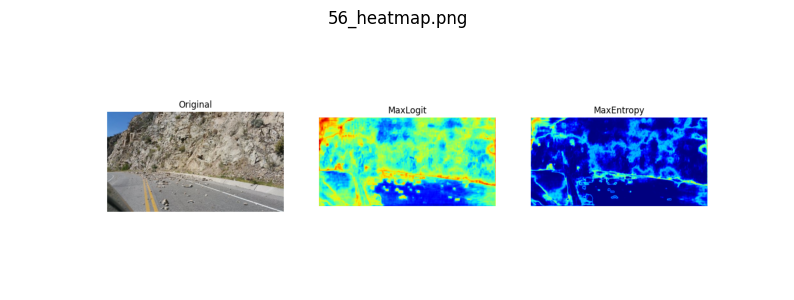

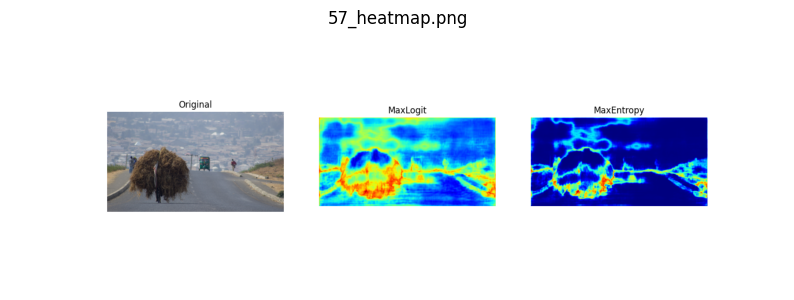

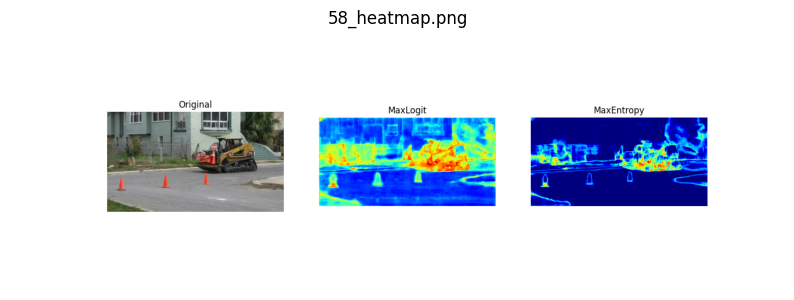

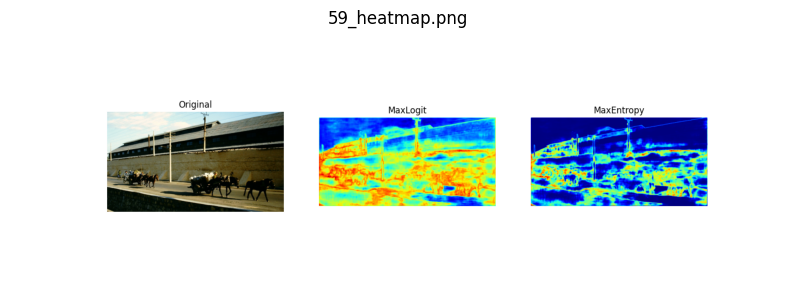

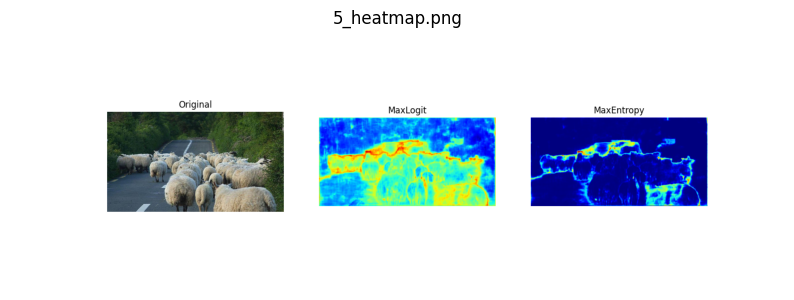

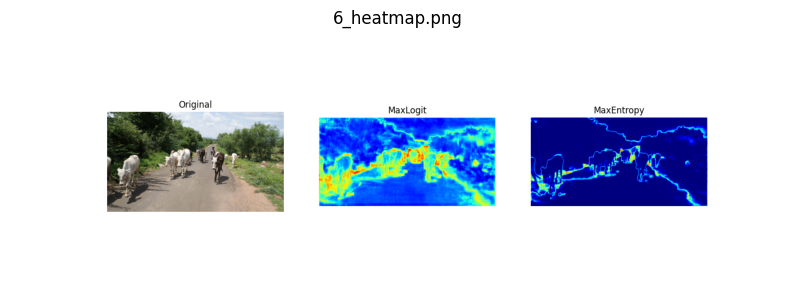

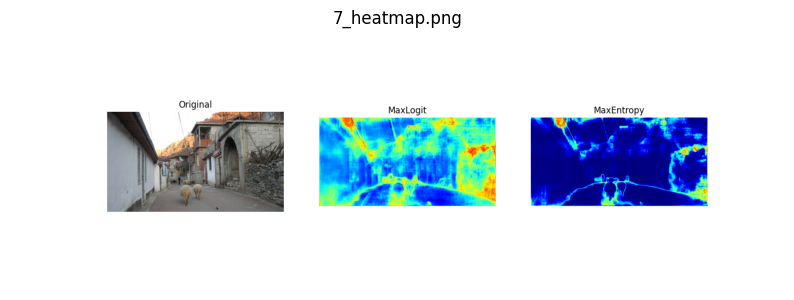

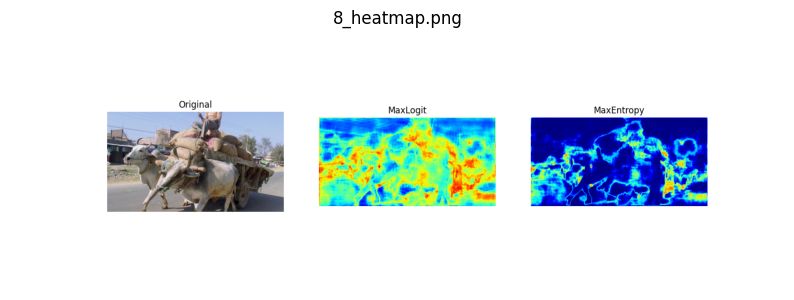

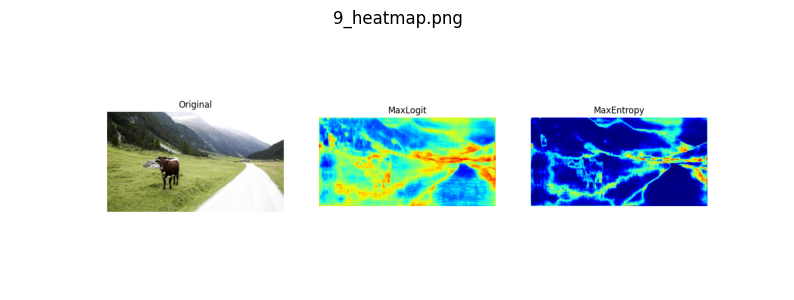

In [ ]:
!python evalAnomaly_logit.py --input "/content/drive/MyDrive/Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/*.jpg"
import os
import matplotlib.pyplot as plt
from PIL import Image
folder = "outputs_heatmaps"
files = sorted(os.listdir(folder))

for file in files:
  path=os.path.join(folder,file)
  img=Image.open(path)
  plt.figure(figsize=(10,5))
  plt.imshow(img)
  plt.title(file)
  plt.axis('off')
  plt.show()